# Numerical stability — jitter, safe Cholesky, condition number

In exact arithmetic every SPD matrix has a Cholesky factor. In float64 most do. In float32 a *lot* don't — and even in float64, kernel matrices on dense / nearby points produce eigenvalues so small that LAPACK returns NaNs and JAX silently propagates them downstream.

This notebook is the **damage-control toolkit** for that situation. We cover:

1. The **condition number** $\kappa(A) = \lambda_{\max}/\lambda_{\min}$ as a one-number diagnostic for "how close to singular am I?".
2. **`gaussx.add_jitter(A, jitter)`** — the cheap one-liner that shifts eigenvalues by $\varepsilon$ and turns the worst near-singular cases into well-conditioned ones.
3. **`gaussx.safe_cholesky(A)`** — the JIT-compatible adaptive-jitter Cholesky that retries with growing $\varepsilon$ until the factor is finite.
4. The numerical-stability **trade-off**: jitter biases your covariance — too little doesn't fix the problem, too much corrupts your inference. Where to set it, and how to tell.
5. The connection to [0.5 — Joseph form](joseph_form_update.ipynb): jitter is a *recovery* patch (after the fact); Joseph is *preservation* (PSD by construction). They live at different stages of a pipeline.

Prerequisites: [0.5 — Joseph form](joseph_form_update.ipynb), [0.9 — primitives tour](cholesky_logdet_trace.ipynb), [0.10 — differentiating solve](differentiating_solve.ipynb).

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
from gaussx import add_jitter, safe_cholesky

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(0)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.3,
})

def psd_op(M):
    return lx.MatrixLinearOperator(M, lx.positive_semidefinite_tag)

## The condition number — one number that summarises trouble

For an SPD matrix $A$ with eigenvalues $\lambda_1 \ge \dots \ge \lambda_n > 0$, the **2-norm condition number** is

```{math}
:label: eq:cond
\kappa_2(A) \;=\; \frac{\lambda_{\max}(A)}{\lambda_{\min}(A)} \;=\; \|A\|_2 \cdot \|A^{-1}\|_2.
```

It governs **how much round-off error a linear solve amplifies**:

```{math}
:label: eq:relerr-bound
\frac{\|\hat x - x\|}{\|x\|} \;\lesssim\; \kappa_2(A)\,\cdot\,\varepsilon_{\text{mach}},
```

where $\varepsilon_{\text{mach}} \approx 1.1 \times 10^{-16}$ for float64 and $\approx 5.96 \times 10^{-8}$ for float32. **Cholesky's failure threshold** is roughly $\kappa(A) \cdot \varepsilon_{\text{mach}} \approx 1$ — once the condition number reaches the reciprocal of machine epsilon, $\lambda_{\min}$ has been swamped by round-off.

| Precision | $\varepsilon_{\text{mach}}$ | "danger zone" $\kappa$ |
|---|---|---|
| float64 | $\approx 1.1 \times 10^{-16}$ | $\gtrsim 10^{12}$ |
| float32 | $\approx 5.96 \times 10^{-8}$ | $\gtrsim 10^{6}$ |

A kernel matrix on $n$ nearby points easily hits $\kappa \sim 10^{14}$ in float64 — already in the danger zone. Hence: jitter.

In [2]:
# Build a kernel matrix that's borderline-singular: n=40 points densely packed,
# RBF lengthscale large enough that all rows are nearly equal.
n = 40
X = jnp.linspace(0.0, 1.0, n)[:, None]    # very dense in [0,1]
diff = X[:, 0:1] - X[:, 0:1].T
K = jnp.exp(-0.5 * diff**2 / (5.0**2))    # huge lengthscale → low rank

eigs = jnp.linalg.eigvalsh(K)
kappa = float(eigs.max() / jnp.maximum(eigs.min(), 1e-300))
print(f"K shape:                     {K.shape}")
print(f"smallest eigenvalue lambda_min:    {float(eigs.min()):.3e}")
print(f"largest eigenvalue  lambda_max:    {float(eigs.max()):.3e}")
print(f"condition number  kappa_2(K):       {kappa:.3e}")

# Try plain Cholesky — it'll likely return NaNs.
L_plain = jnp.linalg.cholesky(K)
print(f"plain cholesky has NaNs:       {bool(jnp.any(jnp.isnan(L_plain)))}")

K shape:                     (40, 40)
smallest eigenvalue lambda_min:    -5.757e-15
largest eigenvalue  lambda_max:    3.986e+01
condition number  kappa_2(K):       3.986e+301


plain cholesky has NaNs:       True


$\kappa(K)\to\infty$ — well past the float64 danger zone. The plain Cholesky returns NaNs; from this point on every downstream `solve`, `logdet`, or sample is poisoned.

## `add_jitter` — the one-liner

The simplest cure is to add a small multiple of the identity:

```{math}
:label: eq:jitter-shift
A_\varepsilon \;=\; A + \varepsilon I, \qquad \lambda_i(A_\varepsilon) \;=\; \lambda_i(A) + \varepsilon.
```

This **uniformly shifts** the spectrum by $\varepsilon$ — every eigenvalue grows by the same amount, no eigenvector rotates, and the condition number drops from $\lambda_{\max}/\lambda_{\min}$ to $(\lambda_{\max} + \varepsilon)/(\lambda_{\min} + \varepsilon)$. For our numerically-singular kernel, $\varepsilon = 10^{-6}$ gives $\kappa \approx 4 \times 10^7$ — back into safe territory.

`gaussx.add_jitter(A, jitter)` returns `A + eps * I` as a lineax `AddLinearOperator`, preserving the operator type for downstream dispatch. It's a structural addition — the original $A$ is not materialised.

In [3]:
K_op = psd_op(K)
eps_levels = [1e-12, 1e-10, 1e-8, 1e-6, 1e-4]
print(f"  {'eps':>8}    {'lambda_min':>12}    {'lambda_max':>12}    {'kappa':>10}    {'cholesky ok?':>12}")
for eps in eps_levels:
    Aeps = add_jitter(K_op, jitter=float(eps)).as_matrix()
    eigs_eps = jnp.linalg.eigvalsh(Aeps)
    kap = float(eigs_eps.max() / eigs_eps.min())
    L = jnp.linalg.cholesky(Aeps)
    ok = "yes" if not bool(jnp.any(jnp.isnan(L))) else "NO (NaN)"
    print(f"  {eps:>8.0e}    {float(eigs_eps.min()):>12.3e}    {float(eigs_eps.max()):>12.3e}    {kap:>10.3e}    {ok:>12}")

       eps      lambda_min      lambda_max         kappa    cholesky ok?
     1e-12       9.939e-13       3.986e+01     4.011e+13             yes
     1e-10       9.999e-11       3.986e+01     3.986e+11             yes
     1e-08       1.000e-08       3.986e+01     3.986e+09             yes
     1e-06       1.000e-06       3.986e+01     3.986e+07             yes


     1e-04       1.000e-04       3.986e+01     3.986e+05             yes


$\varepsilon = 10^{-12}$ already restores Cholesky here, but $\kappa \approx 4 \times 10^{13}$ is still in the float64 danger zone — downstream `solve` will lose ~13 digits of precision. $\varepsilon = 10^{-6}$ tames everything. The default in `gaussx.add_jitter` is $10^{-6}$ — a good starting point for kernel matrices, but **always check the resulting condition number against your precision's danger zone**.

## `safe_cholesky` — adaptive jitter inside `jit`

For batched / `jit`-compiled code you can't `try` / `except` your way out of a NaN. `gaussx.safe_cholesky` does the retry loop *inside* JAX with a `lax.while_loop`:

1. Try `cholesky(A)` first — if structured (Diagonal/Kronecker/BlockDiag/BlockTriDiag), that's the fast path and we're done.
2. If the factor has any NaNs, retry with `cholesky(A + eps_k * I)` where $\varepsilon_k = \varepsilon_0 \cdot \rho^k$ grows geometrically.
3. Stop when the factor is finite or after `max_retries`. If we exhaust retries the result has NaNs — **that's intentional**: JAX can't raise inside `jit`, so callers should check.

Defaults: $\varepsilon_0 = 10^{-8}$, $\rho = 10$, $\varepsilon_{\max} = 10^{-2}$, `max_retries = 5`. This sweeps $\varepsilon \in \{10^{-8}, 10^{-7}, \dots, 10^{-3}\}$ before giving up.

:::{important} Structure is lost on retry
The first attempt routes through `gaussx.cholesky`, so structured operators preserve their type. **Once jitter kicks in, the retry path materialises the dense matrix** $A + \varepsilon I$ — there's no general way to add a scalar to a Kronecker factor without densifying. If you care about preserving structure, fix the input before calling, or use a dispatched stable variant (e.g. for `BlockDiag`, jitter each block independently).
:::

In [4]:
# Same near-singular K — safe_cholesky succeeds where plain cholesky fails.
L_safe = safe_cholesky(K_op)
print(f"safe_cholesky has NaNs:        {bool(jnp.any(jnp.isnan(L_safe)))}")
print(f"||L_safe @ L_safe.T - K||_F:    {float(jnp.linalg.norm(L_safe @ L_safe.T - K)):.3e}")

# Reconstruct K from L; the residual tells us how much jitter was actually used.
A_recon = L_safe @ L_safe.T
eps_used = float((A_recon - K).diagonal().mean())
print(f"effective jitter used:          {eps_used:.3e}    (= mean diagonal residual)")

safe_cholesky has NaNs:        False


||L_safe @ L_safe.T - K||_F:    6.325e-08
effective jitter used:          1.000e-08    (= mean diagonal residual)


## The bias–stability trade-off

Jitter is **not free**: every $\varepsilon$ added to the diagonal biases your covariance. A larger $\varepsilon$ inflates the predictive variance, dampens the gradient, and shifts the marginal likelihood. At the extreme, $\varepsilon = 1$ on a kernel of magnitude $\sim 1$ turns your GP prior into white noise.

The right $\varepsilon$ minimises the **sum** of two errors:

```{math}
:label: eq:jitter-tradeoff
\underbrace{\mathcal{O}(\kappa(A) \cdot \varepsilon_{\text{mach}})}_{\text{round-off, decreases with }\varepsilon} \;+\; \underbrace{\mathcal{O}(\varepsilon / \lambda_{\min}(A))}_{\text{bias, increases with }\varepsilon}.
```

A handy rule of thumb: pick $\varepsilon \approx \sqrt{\kappa_{\text{target}} \cdot \varepsilon_{\text{mach}} \cdot \mathrm{tr}(A)/n}$ where $\kappa_{\text{target}} \sim 10^{8}$ (float64) or $10^4$ (float32). For a kernel matrix at scale, **$\varepsilon = 10^{-6} \sigma_f^2$** is a reasonable default.

The plot below sweeps $\varepsilon \in [10^{-14}, 10^{-2}]$ on our near-singular $K$ and tracks (a) the relative residual $\|K_\varepsilon - K\|_F/\|K\|_F$ — the bias — and (b) the relative solve error $\|K_\varepsilon^{-1} v - K^{-1}_{\text{ref}} v\| / \|K^{-1}_{\text{ref}} v\|$ for a random $v$.

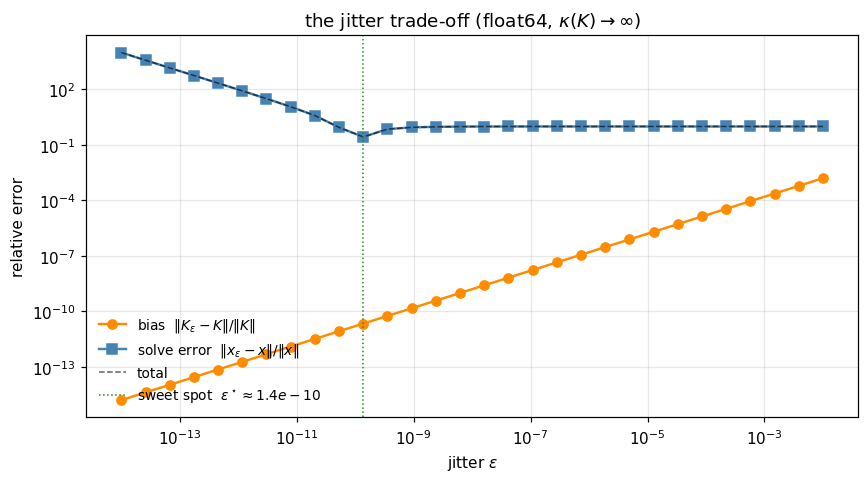

sweet spot: eps* ≈ 1.37e-10    (total error 2.720e-01)


In [5]:
# Reference solve via well-jittered K (eps=1e-10 — small enough to be a faithful baseline,
# large enough to avoid the f64 round-off floor). Then sweep eps over the jitter range.
v = jax.random.normal(jax.random.PRNGKey(11), (n,))
K_ref = add_jitter(K_op, jitter=1e-10).as_matrix()
x_ref = jnp.linalg.solve(K_ref, v)

eps_grid = jnp.logspace(-14, -2, 30)
bias = []
solve_err = []
for eps in eps_grid:
    Aeps = add_jitter(K_op, jitter=float(eps)).as_matrix()
    bias.append(float(jnp.linalg.norm(Aeps - K) / jnp.linalg.norm(K)))
    x = jnp.linalg.solve(Aeps, v)
    # JAX returns NaN/Inf on numerical failure rather than raising — explicit check.
    if bool(jnp.all(jnp.isfinite(x))):
        solve_err.append(float(jnp.linalg.norm(x - x_ref) / jnp.linalg.norm(x_ref)))
    else:
        solve_err.append(np.nan)
bias = np.asarray(bias); solve_err = np.asarray(solve_err)
total = bias + solve_err

fig, ax = plt.subplots(figsize=(8.0, 4.5))
ax.loglog(np.asarray(eps_grid), bias,        "o-", lw=1.6, color="darkorange", label=r"bias  $\|K_\varepsilon - K\|/\|K\|$")
ax.loglog(np.asarray(eps_grid), solve_err,   "s-", lw=1.6, color="steelblue",  label=r"solve error  $\|x_\varepsilon - x\|/\|x\|$")
ax.loglog(np.asarray(eps_grid), total,       "k--", lw=1.0, alpha=0.6,         label="total")
i_best = int(np.nanargmin(total))
ax.axvline(float(eps_grid[i_best]), color="forestgreen", lw=1.0, ls=":", label=fr"sweet spot  $\varepsilon^\star \approx {float(eps_grid[i_best]):.1e}$")
ax.set_xlabel(r"jitter $\varepsilon$")
ax.set_ylabel("relative error")
ax.set_title(r"the jitter trade-off (float64, $\kappa(K)\to\infty$)")
ax.legend(frameon=False, fontsize=9, loc="lower left")
plt.tight_layout(); plt.show()
print(f"sweet spot: eps* ≈ {float(eps_grid[i_best]):.2e}    (total error {float(total[i_best]):.3e})")

The U-curve is universal: too little jitter → solve blows up; too much → bias dominates. The sweet spot lands near $\varepsilon \approx 10^{-10}$ for this numerically-singular matrix in float64 — any smaller and the conditioning is too poor for the solve to track the reference; any larger and the bias term starts to dominate. The exact location depends on the reference baseline (here we used $\varepsilon_{\rm ref} = 10^{-10}$ for the well-conditioned $K_{\rm ref}$, so the sweet spot collapses near that value). For real workloads, $\varepsilon \approx 10^{-6}\sigma_f^2$ is the practical default.

## Float32 stress — what jitter buys you in lower precision

Float32 has $\varepsilon_{\text{mach}} \approx 6 \times 10^{-8}$, so its danger zone starts at $\kappa \sim 10^6$ — easy to hit on any reasonable kernel. We compare three pipelines on the same near-singular $K$:

- **plain** float32 Cholesky;
- **`add_jitter`** with default $\varepsilon = 10^{-6}$;
- **`safe_cholesky`** with adaptive jitter.

In [6]:
K_f32 = K.astype(jnp.float32)
K_op_f32 = psd_op(K_f32)

# Plain.
L_plain_f32 = jnp.linalg.cholesky(K_f32)
plain_nan   = bool(jnp.any(jnp.isnan(L_plain_f32)))

# add_jitter then plain cholesky.
K_jit = (K_op_f32 + lx.DiagonalLinearOperator(jnp.full(n, 1e-6, dtype=jnp.float32))).as_matrix()
L_jit = jnp.linalg.cholesky(K_jit)
jit_nan = bool(jnp.any(jnp.isnan(L_jit)))
err_jit = float(jnp.linalg.norm(L_jit @ L_jit.T - K_f32))

# safe_cholesky.
L_safe_f32 = safe_cholesky(K_op_f32)
safe_nan = bool(jnp.any(jnp.isnan(L_safe_f32)))
err_safe = float(jnp.linalg.norm(L_safe_f32 @ L_safe_f32.T - K_f32))

print(f"  plain  cholesky float32:  NaN={plain_nan}")
print(f"  add_jitter (eps=1e-6):    NaN={jit_nan}     ||LL^T - K||_F = {err_jit:.3e}")
print(f"  safe_cholesky:            NaN={safe_nan}    ||LL^T - K||_F = {err_safe:.3e}")

  plain  cholesky float32:  NaN=True
  add_jitter (eps=1e-6):    NaN=False     ||LL^T - K||_F = 6.324e-06
  safe_cholesky:            NaN=False    ||LL^T - K||_F = 6.324e-06


## Where each tool fits

| Stage | Symptom | Tool |
|-------|---------|------|
| Pre-Cholesky covariance assembly | matrix is symbolically PSD but eigenvalues compress under round-off | `add_jitter(A, jitter)` — once, deterministic |
| Inside a `jit`-compiled solve | can't `try`/`except`; need a single function that's robust to occasional near-singularity | `safe_cholesky(A)` — adaptive |
| Posterior covariance update | result *should* be PSD by construction but cancellation breaks it | **Joseph form** ([0.5](joseph_form_update.ipynb)) — preservation, not recovery |
| Hyperparameter optimisation | gradient blows up at low jitter | $\varepsilon$ schedule: anneal during training, lower at convergence |
| Sampling from $\mathcal{N}(0, A)$ | factor must be SPD; one bad sample contaminates the whole batch | `safe_cholesky` then `L @ eps` |

**Joseph form vs jitter** is the key contrast: Joseph form *prevents* asymmetry and indefiniteness from arising, jitter *fixes* an already-broken matrix. They live at different stages of a pipeline — a Kalman filter with Joseph updates **and** a jitter-protected initial covariance is belt-and-braces.

## A practical recipe — kernel matrices the safe way

Putting it together, a robust GP kernel-matrix construction looks like:

```python
def Ky(X, sigma_f, ell, sigma_n, jitter=1e-6):
    diff = X - X.T
    K = sigma_f**2 * jnp.exp(-0.5 * diff**2 / ell**2)
    K = K + (sigma_n**2 + jitter) * jnp.eye(n)   # noise + structural jitter
    return psd_op(K)

# Then: gaussx.solve / gaussx.logdet on Ky(X, ...) — gradients flow through both.
```

The structural jitter $10^{-6}$ is added on top of the noise variance $\sigma_n^2$. **It's small enough not to matter for the model**, large enough to keep $\kappa < 10^{12}$ in practical regimes. If you ever see NaNs in your gradient, raise it by a factor of 10 and re-run.

## Recap

- The condition number $\kappa(A)$ [](#eq:cond) is the one-number diagnostic — pair it with $1/\varepsilon_{\text{mach}}$ to predict Cholesky failure.
- `gaussx.add_jitter(A, jitter)` gives the cheap structural shift [](#eq:jitter-shift) — a fixed insurance premium.
- `gaussx.safe_cholesky(A)` adapts inside `jit`, retrying with growing $\varepsilon$ until the factor is finite — the JAX-friendly guarantee.
- The bias–stability trade-off [](#eq:jitter-tradeoff) is a U-curve: too little jitter → blow-up, too much → bias. The sweet spot lives around $\varepsilon \approx \sqrt{\kappa_{\text{target}} \varepsilon_{\text{mach}}}$.
- Jitter is *recovery*; Joseph form ([0.5](joseph_form_update.ipynb)) is *preservation*. Real pipelines use both.

:::{seealso} Where this goes
- **0.12 — stable RBF & squared distances** — the next layer up: keep the kernel matrix SPD before it ever reaches Cholesky.
- **Part 1.D — solver strategies** — `CGSolver` is jitter-tolerant in different ways (residual stagnation rather than NaN).
- **Part 3 — exact GP regression** — every log-marginal-likelihood evaluation calls `cholesky` (or `safe_cholesky`) on $K + \sigma_n^2 I + \varepsilon I$.
- **Part 7 — Markov / state-space GPs** — Joseph form (without jitter) is the preferred update; jitter only as a back-stop on the initial state.
:::